# Usage Notes

This notebook shows practical examples for working with the data from A multiresolution weather dataset for the Southwestern South Atlantic (2017-2018) **xarray**:

- Calculating **wind speed** from wind components
- Retrieving **wind components at different heights**
- Selecting the **nearest grid-point value**
- Saving data to **csv file**

## libraries

In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap

## data loading

In [36]:
data_20170206_D01 = xr.open_dataset('/total/dataset_total/dados/D01/2017/data_D01_20170206.nc')
data_20170206_D02 = xr.open_dataset('/total/dataset_total/dados/D02/2017/data_D02_20170206.nc')
data_20170206_D03 = xr.open_dataset('/total/dataset_total/dados/D03/2017/data_D03_20170206.nc')

## Data exploration

### Data for February 6, 2018, D01 grid

In [14]:
data_20170206_D01

<xarray.Dataset>
Dimensions:   (Time: 35, south_north: 354, west_east: 360, bottom_top: 4,
               bottom_top_stag: 5, west_east_stag: 361, south_north_stag: 355)
Coordinates:
    XLAT      (south_north, west_east) float32 ...
    XLONG     (south_north, west_east) float32 ...
    Times     (Time) object ...
    XLAT_U    (south_north, west_east_stag) float32 ...
    XLONG_U   (south_north, west_east_stag) float32 ...
    XLAT_V    (south_north_stag, west_east) float32 ...
    XLONG_V   (south_north_stag, west_east) float32 ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, west_east_stag,
                                south_north_stag
Data variables: (12/21)
    T2        (Time, south_north, west_east) float32 ...
    TH2       (Time, south_north, west_east) float32 ...
    SST       (Time, south_north, west_east) float32 ...
    PSFC      (Time, south_north, west_east) float32 ...
    RAINC     (Time, south_north, west_east) float32 ...
    RAINNC    (Time, south_north, west_east) float32 ...
    ...        ...
    P         (Time, bottom_top, south_north, west_east) float32 ...
    PH        (Time, bottom_top_stag, south_north, west_east) float32 ...
    T         (Time, bottom_top, south_north, west_east) float32 ...
    U         (Time, bottom_top, south_north, west_east_stag) float32 ...
    V         (Time, bottom_top, south_north_stag, west_east) float32 ...
    W         (Time, bottom_top_stag, south_north, west_east) float32 ...
Attributes: (12/148)
    TITLE:                            OUTPUT FROM WRF V4.3.3 MODEL
    WEST-EAST_GRID_DIMENSION:        361
    SOUTH-NORTH_GRID_DIMENSION:      355
    BOTTOM-TOP_GRID_DIMENSION:       45
    DX:                              9000.0
    DY:                              9000.0
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

#### Terrain height above sea level (HGT)

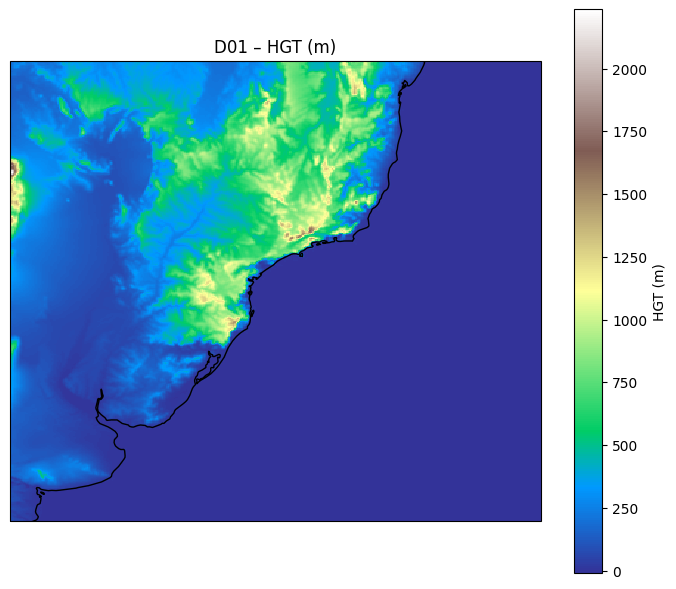

In [10]:
# positions and heights
lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]
hgt = data_20170206_D01["HGT"]

# plot
plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, hgt,
    cmap="terrain",
    shading="auto"
)

ax.coastlines()
ax.set_title("D01 – HGT (m)")

plt.colorbar(im, ax=ax, label="HGT (m)")
plt.tight_layout()
plt.show()

# close data file to save memory
data_20170206_D01.close()

#### Land Use Index

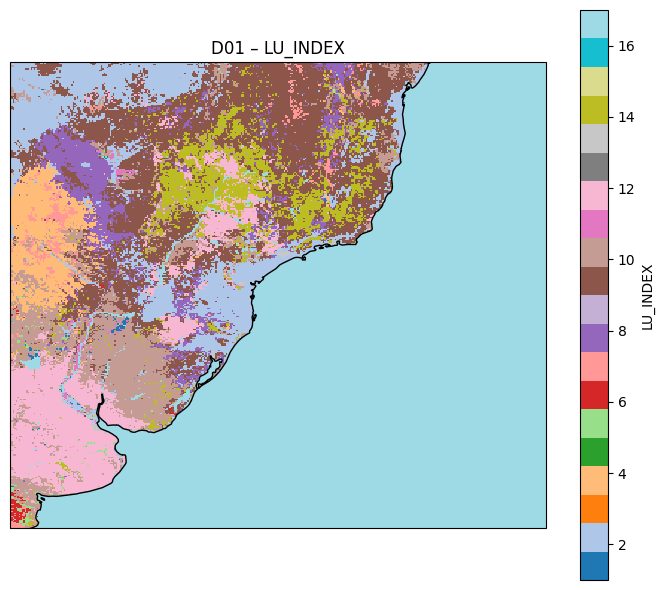

In [9]:
lon = data_20170206_D02["XLONG"]
lat = data_20170206_D02["XLAT"]
lu = data_20170206_D02["LU_INDEX"]


plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, lu,
    cmap="tab20",      # categorical-friendly colormap
    shading="auto"
)

ax.coastlines()
ax.set_title("D01 – LU_INDEX")

plt.colorbar(im, ax=ax, label="LU_INDEX")
plt.tight_layout()
plt.show()


### Calculating wind speed at 10 m height

In [13]:
# read wind components (all times)
u10 = data_20170206_D01["U10"]   # (Time, south_north, west_east)
v10 = data_20170206_D01["V10"]

# calculate wind speed for ALL times (m/s)
wspd = np.sqrt(u10**2 + v10**2)

#### plotting wind speed at 10 m height

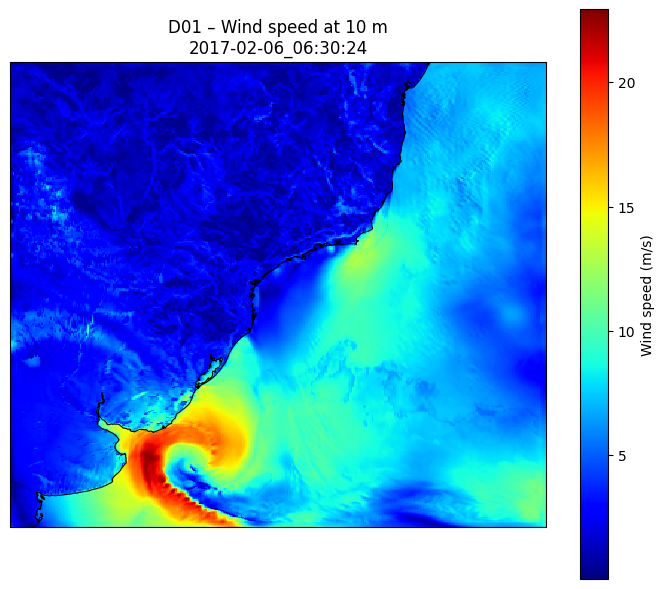

In [15]:
# select time index
tidx = 0  # change this to any Time index you want

ws_t = wspd.isel(Time=tidx)

lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]

# extract time string
time_str = (
    data_20170206_D01["Times"]
    .isel(Time=tidx)
    .values
)

# plot
plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon,
    lat,
    ws_t,
    cmap="jet",
    shading="auto"
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.set_title(f"D01 – Wind speed at 10 m\n{time_str}")

plt.colorbar(im, ax=ax, label="Wind speed (m/s)")
plt.tight_layout()
plt.show()

#### Ploting U wind component

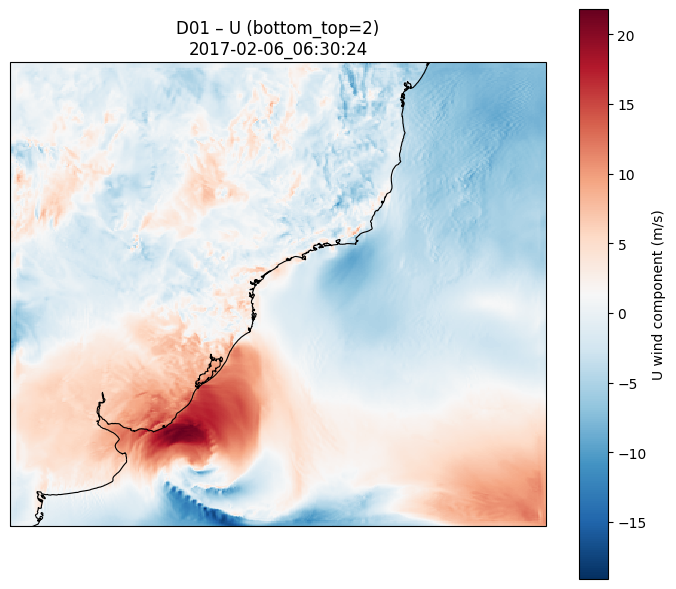

In [22]:
# --- select time and vertical level ---
time_index = 0
vertical_level = 2  # bottom_top index

# --- select U at fixed time/height (no unstaggering) ---
u = data_20170206_D01["U"].isel(Time=time_index, bottom_top=vertical_level)

# --- lon/lat on U grid ---
lon_u = data_20170206_D01["XLONG_U"]
lat_u = data_20170206_D01["XLAT_U"]

# --- extract time string ---
time_str = (
    data_20170206_D01["Times"]
    .isel(Time=time_index)
    .values
    .astype(str)
    .item()
)

# --- plot ---
fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_u, lat_u, u,
    cmap="RdBu_r",
    shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.set_title(f"D01 – U (bottom_top={vertical_level})\n{time_str}")

plt.colorbar(im, ax=ax, label="U wind component (m/s)")
plt.tight_layout()
plt.show()

### Exporting D03 data to csv

In [23]:
data_20170206_D03 

<xarray.Dataset>
Dimensions:   (Time: 35, south_north: 354, west_east: 360, bottom_top: 4,
               bottom_top_stag: 5, west_east_stag: 361, south_north_stag: 355)
Coordinates:
    XLAT      (south_north, west_east) float32 ...
    XLONG     (south_north, west_east) float32 ...
    Times     (Time) object ...
    XLAT_U    (south_north, west_east_stag) float32 ...
    XLONG_U   (south_north, west_east_stag) float32 ...
    XLAT_V    (south_north_stag, west_east) float32 ...
    XLONG_V   (south_north_stag, west_east) float32 ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, west_east_stag,
                                south_north_stag
Data variables: (12/21)
    T2        (Time, south_north, west_east) float32 ...
    TH2       (Time, south_north, west_east) float32 ...
    SST       (Time, south_north, west_east) float32 ...
    PSFC      (Time, south_north, west_east) float32 ...
    RAINC     (Time, south_north, west_east) float32 ...
    RAINNC    (Time, south_north, west_east) float32 ...
    ...        ...
    P         (Time, bottom_top, south_north, west_east) float32 ...
    PH        (Time, bottom_top_stag, south_north, west_east) float32 ...
    T         (Time, bottom_top, south_north, west_east) float32 ...
    U         (Time, bottom_top, south_north, west_east_stag) float32 ...
    V         (Time, bottom_top, south_north_stag, west_east) float32 ...
    W         (Time, bottom_top_stag, south_north, west_east) float32 ...
Attributes: (12/148)
    TITLE:                            OUTPUT FROM WRF V4.3.3 MODEL
    WEST-EAST_GRID_DIMENSION:        361
    SOUTH-NORTH_GRID_DIMENSION:      355
    BOTTOM-TOP_GRID_DIMENSION:       45
    DX:                              9000.0
    DY:                              9000.0
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

In [39]:
import numpy as np
import pandas as pd

# ============================================================
# USER INPUT (set these first)
# ============================================================
lat0 = -27.50
lon0 = -48.30

ds = data_20170206_D03 

out_csv = "example_u10_v10_timeseries.csv"

# ============================================================
# 1) Get 2D lat/lon (mass grid) and drop optional Time dim
# ============================================================
lat_da = ds["XLAT"]
lon_da = ds["XLONG"]

if "Time" in lat_da.dims:
    lat_da = lat_da.isel(Time=0)
    lon_da = lon_da.isel(Time=0)

lat2d = lat_da.values
lon2d = lon_da.values

# ============================================================
# 2) Warn if outside grid bounding box (simple check)
# ============================================================
lat_min = float(np.nanmin(lat2d))
lat_max = float(np.nanmax(lat2d))
lon_min = float(np.nanmin(lon2d))
lon_max = float(np.nanmax(lon2d))

outside = (lat0 < lat_min) or (lat0 > lat_max) or (lon0 < lon_min) or (lon0 > lon_max)
if outside:
    print(
        f"⚠️ Point ({lat0:.5f}, {lon0:.5f}) is outside grid bounding box:\n"
        f"    lat range: [{lat_min:.5f}, {lat_max:.5f}]\n"
        f"    lon range: [{lon_min:.5f}, {lon_max:.5f}]"
    )

# ============================================================
# 3) Find closest grid point using haversine distance (km)
# ============================================================
R = 6371.0  # km

lat_rad = np.deg2rad(lat2d)
lon_rad = np.deg2rad(lon2d)
lat0r = np.deg2rad(lat0)
lon0r = np.deg2rad(lon0)

dlat = lat_rad - lat0r
dlon = lon_rad - lon0r

a = np.sin(dlat / 2.0) ** 2 + np.cos(lat0r) * np.cos(lat_rad) * np.sin(dlon / 2.0) ** 2
c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
dist_km = R * c

flat_idx = int(np.nanargmin(dist_km))
j, i = np.unravel_index(flat_idx, dist_km.shape)
d_km = float(dist_km[j, i])

closest_lat = float(lat2d[j, i])
closest_lon = float(lon2d[j, i])

print("\n📍 Closest grid point (mass grid: XLAT/XLONG)")
print(f"Target lat/lon : ({lat0:.5f}, {lon0:.5f})")
print(f"Closest ij     : ({j}, {i})")
print(f"Closest lat/lon: ({closest_lat:.5f}, {closest_lon:.5f})")
print(f"Distance       : {d_km:.2f} km")

# ============================================================
# 4) Extract U10/V10 for ALL times at that grid point
# ============================================================
u10_ts = ds["U10"].isel(south_north=j, west_east=i).values
v10_ts = ds["V10"].isel(south_north=j, west_east=i).values

nT = ds.sizes["Time"]
time_strs = [
    ds["Times"].isel(Time=t).values.astype(str).item()
    for t in range(nT)
]

# ============================================================
# 5) Save to CSV
# ============================================================
df = pd.DataFrame(
    {
        "time_str": time_strs,
        "U10_mps": u10_ts.astype(float),
        "V10_mps": v10_ts.astype(float),
        "target_lat": lat0,
        "target_lon": lon0,
        "closest_lat": closest_lat,
        "closest_lon": closest_lon,
        "distance_km": d_km,
    }
)

df.to_csv(out_csv, index=False)
print(f"\n✅ Saved {len(df)} rows to: {out_csv}")


📍 Closest grid point (mass grid: XLAT/XLONG)
Target lat/lon : (-27.50000, -48.30000)
Closest ij     : (137, 55)
Closest lat/lon: (-27.50346, -48.30394)
Distance       : 0.55 km

✅ Saved 35 rows to: example_u10_v10_timeseries.csv
